In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [2]:
VOCAB_SIZE = 10000

(x_train, y_train), (x_test, y_test) = imdb.load_data(
    num_words=VOCAB_SIZE
)

In [3]:
print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))

print("\nFirst review:")
print(x_train[0])

print("\nFirst label:")
print(y_train[0])

Training samples: 25000
Testing samples: 25000

First review:
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32

In [4]:
word_index = imdb.get_word_index()

reverse_word_index = {
    index + 3: word
    for word, index in word_index.items()
}

reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"

decoded_review = " ".join(
    reverse_word_index.get(i, "?")
    for i in x_train[0]
)

print(decoded_review)
print("\nSentiment:", "Positive" if y_train[0] == 1 else "Negative")

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also <UNK> to the two little boy's that played the <UNK> of norman and paul they were just brilliant children are often left out of the <UNK> list i think because the stars that play them all grown up are such a big profile for the whole film but these c

In [5]:
MAX_LENGTH = 250

x_train = pad_sequences(
    x_train,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

x_test = pad_sequences(
    x_test,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

In [6]:
print("Training shape:", x_train.shape)
print("Testing shape:", x_test.shape)

Training shape: (25000, 250)
Testing shape: (25000, 250)


In [9]:
EMBEDDING_DIM = 128
LSTM_UNITS = 64

model = tf.keras.models.Sequential([
    tf.keras.layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        mask_zero=True
    ),

    tf.keras.layers.LSTM(LSTM_UNITS),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])

In [10]:
model.build(input_shape=(None, MAX_LENGTH))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 250, 128)            │       1,280,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,329,473 (5.07 MB)

 Trainable params: 1,329,473 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# compile the model
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [12]:
# train the model
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 109s 309ms/step - accuracy: 0.7709 - loss: 0.4771 - val_accuracy: 0.8454 - val_loss: 0.3596
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 55s 175ms/step - accuracy: 0.8909 - loss: 0.2825 - val_accuracy: 0.8682 - val_loss: 0.3357
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 53s 170ms/step - accuracy: 0.9115 - loss: 0.2305 - val_accuracy: 0.8696 - val_loss: 0.3339
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 53s 171ms/step - accuracy: 0.9433 - loss: 0.1613 - val_accuracy: 0.8610 - val_loss: 0.4044
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 52s 165ms/step - accuracy: 0.9552 - loss: 0.1288 - val_accuracy: 0.8630 - val_loss: 0.4775


In [18]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.8406 - loss: 0.5600
Test Loss: 0.5599683523178101
Test Accuracy: 0.8405600190162659


In [19]:
y_prob = model.predict(x_test)
y_pred = (y_prob >= 0.5).astype("int32").flatten()
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step
[[11186  1314]
 [ 2672  9828]]


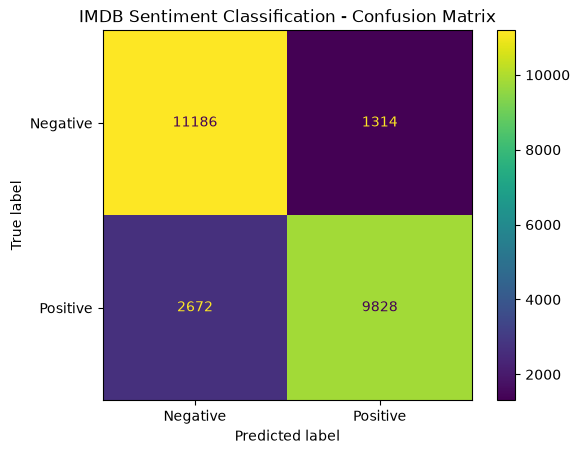

In [15]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("IMDB Sentiment Classification - Confusion Matrix")
plt.show()

In [20]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Negative", "Positive"]
    )
)

              precision    recall  f1-score   support

    Negative       0.81      0.89      0.85     12500
    Positive       0.88      0.79      0.83     12500

    accuracy                           0.84     25000
   macro avg       0.84      0.84      0.84     25000
weighted avg       0.84      0.84      0.84     25000

